# Score based diffusion models

## Суть
Что бы сэмплировать из больших распределений, нужно знать скор функцию.

Диффузые модели учат функцию сонаправленную скор функции ${\color{DarkViolet}\nabla log(p_t(x))}$.

Все остальное - это методы выучить эту скор функцию из датасета и методы сэмплирования.

## Теория


Если у нас есть SDE (Stochastic differencial equation):

$ \partial x = {\color{Aqua}f(x, t)}\partial t + {\color{red}g(t)}\partial \omega$

Где:

1) ${\color{Aqua}f(x, t)}\partial t$ представляет общее движение
2) ${\color{red}g(t)}\partial \omega$ представляет случайные процессы, по модулю ${\color{red}g(t)}$

Тогда для него существует обратное во времени уравнение (Reverse SDE):

$ \partial x = [{\color{Aqua}f(x, t)} - {\color{red}g^2(t)}{\color{DarkViolet}\nabla log(p_t(x))}]\partial t + {\color{red}g(t)}\partial \={\omega}$

Где ${\color{DarkViolet}\nabla log(p_t(x))}$ это то что называется "score function".


Мы можем использовать первое уравнение что бы зашумлить наши данные, и второе что бы восстановить. Т.е решая Reverse SDE для случайной точки, мы можем сэмплировать из распределения $\color{DarkViolet}p(x)$

Но какую взять функцию ${\color{Aqua}f(x, t)}$?

Мы можем использовать разные функции (я пока что не знаю какие еще кроме той что используется сейчас и сдесь), например метод зашумления из DDPM возможно переписать как SDE.
В DDPM определяем процесс по зашумлению данных как:

$x_{i + 1} = \sqrt{\alpha_i}x_i + \sqrt{1-\alpha_i}\epsilon_{i-1}$,
где $1 - \alpha$ это дисперсия

Почему так? Потому что определив шум таким образом, получается выразить любой шаг через i напрямую:

$x_i = \sqrt{\=\alpha_i}x_0 + \sqrt{1-\=\alpha_i}\epsilon_{i-1}$

Это можно увидеть если подставить $x_i$ в рекурентную формулу

Теперь введем новую переменную $\beta_i = 1 - \=\alpha_i$, тогда выражение становится

$x_{i + 1} = \sqrt{1 - \beta_i}x_{i} + \sqrt{\beta_i}\epsilon_{i-1}$
Теперь введем $\~\beta_i = \beta_iN$
Выражеине станвоится
$x_i = \sqrt{1 - \frac{\~\beta_i}{N}}x_i + \sqrt{\frac{\~\beta_i}{N}}\epsilon_{i-1}$

Теперь репеинтертируем индекс как функцию от времени, где $\varDelta t = \frac{1}{N}$

$x(t + \varDelta t) = \sqrt{1 - \beta_i(t + \varDelta t) \varDelta t}x(t) + \sqrt{\beta_i(t + \varDelta t) \varDelta t}\epsilon(t)$

Теперь, используем ряд тейлора для $\sqrt{x}$, упростив выражение (мы можем взять конечное число членов из ряда, поскольку полагаем что $\varDelta t \rightarrow 0$)

$x(t + \varDelta t) = \frac{1}{2}(2 - \beta(t + \varDelta t) \varDelta t)x(t) + \sqrt{\beta(t + \varDelta t) \varDelta t}\epsilon(t)$

$x(t + \varDelta t) = x(t) - x(t)\frac{1}{2}\beta(t + \varDelta t) \varDelta t + \sqrt{\beta(t + \varDelta t) \varDelta t}\epsilon(t)$

В итоге получаем

$\partial x = -x\frac{1}{2}\beta(t)\partial t + \sqrt{\beta(t) \partial t}\epsilon(t) = -x\frac{1}{2}\beta(t)\partial t + \sqrt{\beta(t)}\sqrt{\partial t}\epsilon(t)$

Почему то $\sqrt{\partial t}\epsilon(t) = \partial\omega$

$\partial x = -x\frac{1}{2}\beta(t)\partial t + \sqrt{\beta(t)}\partial\omega$

Тепер у нас есть SDE, которое можно реверснуть

$$
\color{Aqua}-x\frac{1}{2}\beta(t) = f(x, t) \\
\color{Red}\sqrt{\beta(t)} = g(t)
$$
Что бы решить уравнение назад во времени, нам нужно знать

${\color{DarkViolet}\nabla log(p_t(x))}$

Мы не знаем ее, но можем попытатся аппроксимировать ее, используя модель, минимизируя математическое ожидание 

$L = \mathbb{E}_{x_0\sim p(x)} [\lVert s_\theta - {\color{DarkViolet}\nabla log(p_t(x))}\rVert^2]$

Однако, мы не знаем его, по этому данное выражение не подходит.

К счатью, для достаточно большой выборки задача минимизации становится эквивалента

$L = \mathbb{E}_{x_0\sim p(x)} [\lVert s_\theta - {\color{DarkViolet}\nabla log(p_t(x | x_0))}\rVert^2]$

Это можно представить как если мы заставляем модель выучить направление к среднему всего распределения на больших уровнях шума, и "локальному" среднему на маленьких.
Т.е из $x_0$ в $x_t$ ведет бесконечное количество путей, т.е из разных примеров мы будем попадать в +- один и тот же $x_t$, и разнообразие семьи возможных $x_0$ будет зависить от уровня добавленного шума. Тогда, модель будет учится предсказывать среднее для конкретной семьи возможных $x_0$. Именно поэтому модели необходимо знать степень зашумленности, иначе она будет учится среднему всего датасета.

Теперь что бы получить 
${\color{DarkViolet}\nabla log(p_t(x))}$ 
мы можем воспользоваться удивительным математическим фактом того, что определяя процесс зашумления, мы можем выразить ${\color{DarkViolet}\nabla log(p_t(x| x_0))}$ через шум $\color{red}\epsilon$

Процесс $ x_{t+1} = \sqrt{\=\alpha_t}x_t + \sqrt{1 - \=\alpha_t}{\color{red}\epsilon}$ можно переписать как 

$x_t \sim \aleph(x_t; \sqrt{\=\alpha_t}x_0, (1 - \=\alpha_t)I)$,

где
1) $\sqrt{\=\alpha_t}x_0$ среднее
2) $(1 - \=\alpha_t)I$ дисперсия

найдя логарифмический градиент функции плотности нормального распределения для этого варианта, мы получим

$\color{DarkViolet}\nabla log(p_t(x | x_0)) = - \frac{1}{1 - \=\alpha_t}(x_t - \sqrt{\=\alpha_t}x_0)$

Если выразить шум из формулы зашумления, то получим то же самое выражение, но с другим знаком.

$\color{red}\epsilon = \frac{x_t - \sqrt{\=\alpha_t}x_0}{\sqrt{1 - \=\alpha_t}}$

${\color{DarkViolet}\nabla log(p_t(x | x_0))} =\color{red}-\epsilon$
Таким образом, цель минимизации превращается в

$L = \mathbb{E}_{x_0\sim p(x), {\color{red}\epsilon} \sim \aleph(0, 1)} [\lVert s_\theta + {\color{red}\epsilon}\rVert^2]$


## TODO
0) добавить как появляется метод дискритизации эйлера маруямы
1) Добавить информацию о сэмплирвоании (не только метод эйлера маруямы)

## Реализация алгоритма зашумления

In [12]:
import tensorflow as tf
import numpy as np
from keras.datasets import mnist
import matplotlib.pyplot as plt

In [ ]:
from math import floor

class noiser:
    def __init__(self, beta_schedule = None):
        if beta_schedule is None:
            beta_schedule = tf.linspace(0.001, 0.02, 100)
        self.beta = beta_schedule
        self.num_steps = self.beta.shape[0]
        self.alphas = 1.0 - self.beta
        self.alphas_bar = tf.math.cumprod(self.alphas)

    def forward(self, x, time = None):
        if time is None:
            time = tf.random.uniform((1,), 0, 1)
        index = floor(time*tf.shape(self.beta)[0].numpy())
        if index >= self.num_steps:
            index = self.num_steps - 1
        noise = tf.random.normal(tf.shape(x))
        return x*tf.sqrt(self.alphas_bar[index]) + noise * tf.sqrt(1 - self.alphas_bar[index]), noise

    def backward_euler_maruyama(self, x = None, x_shape = None):
        time = tf.linspace(1, 0, self.num_steps)
        if x is None:
            x = tf.random.
        for t, beta, alpha, alpha_bar in zip(time, self.beta, self.alphas, self.alphas_bar):
            pass


In [14]:
B = tf.linspace(0.001, 0.02, 100)
s = tf.shape(B)
tf.floor(tf.random.uniform((1,), 0, 1)*s[0].numpy())

<tf.Tensor: shape=(1,), dtype=float32, numpy=array([22.], dtype=float32)>

### Проверка алгоритма зашумления

In [15]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

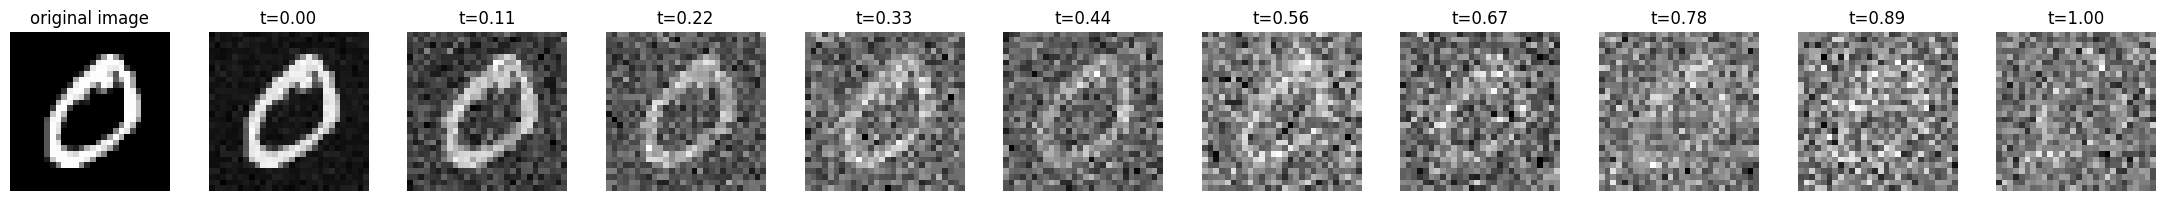

In [ ]:
test_noiser = noiser()
img = x_train[1].astype(np.float32) / 255.0
num_steps = 10
fig, axes = plt.subplots(1, num_steps + 1, figsize=(2 * (num_steps + 1), 2))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('original image')
axes[0].axis('off')

for i, t in enumerate(np.linspace(0, 1, num_steps)):
    noised_img = test_noiser.forward(img, time=tf.constant([t], dtype=tf.float32))[0]
    axes[i + 1].imshow(noised_img.numpy(), cmap='gray')
    axes[i + 1].set_title(f"t={t:.2f}")
    axes[i + 1].axis('off')

plt.tight_layout()
plt.show()